In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def display(img,cmap='gray'):
  fig=plt.figure(figsize=(8,6))
  ax=fig.add_subplot(111)
  ax.imshow(img,cmap='gray')

In [4]:
sep_coins = cv2.imread(r'C:\Users\arpit\Desktop\Image_Fundamentals\Udemy_Pierian_Data_OpenCV\Computer-Vision-with-Python\DATA\pennies.jpg')

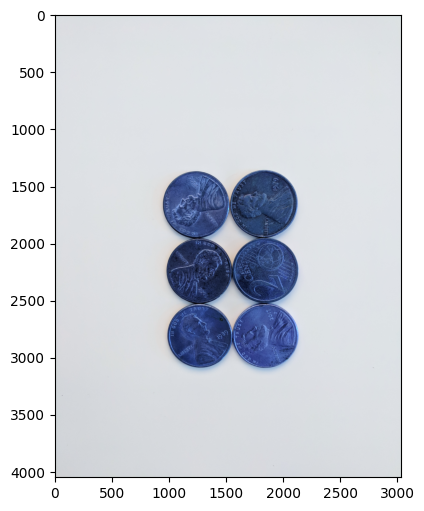

In [5]:
display(sep_coins)

- Median Blur
- Grayscale
- Binary Threshold
- Find Contours

In [6]:
sep_blur = cv2.medianBlur(sep_coins,25)

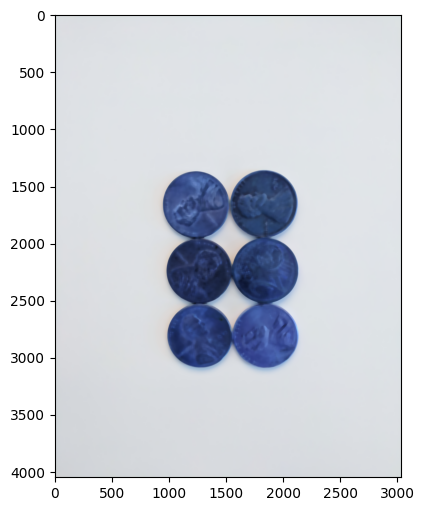

In [7]:
display(sep_blur)

In [8]:
gray_sep_coins = cv2.cvtColor(sep_blur, cv2.COLOR_BGR2GRAY)

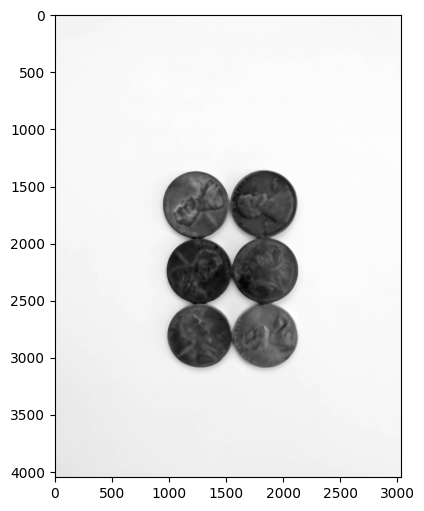

In [9]:
display(gray_sep_coins)

In [10]:
ret, sep_thresh = cv2.threshold(gray_sep_coins,160,255,cv2.THRESH_BINARY_INV)

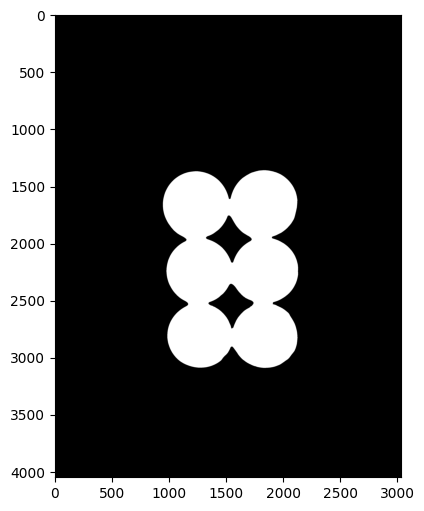

In [11]:
display(sep_thresh)

In [12]:
contours,heirarchy = cv2.findContours(sep_thresh.copy(),cv2.RETR_CCOMP,cv2.CHAIN_APPROX_SIMPLE)

In [13]:
for i in range(len(contours)):

  if heirarchy[0][i][3] == -1:
    cv2.drawContours(sep_coins,contours,i,(255,0,0),10)

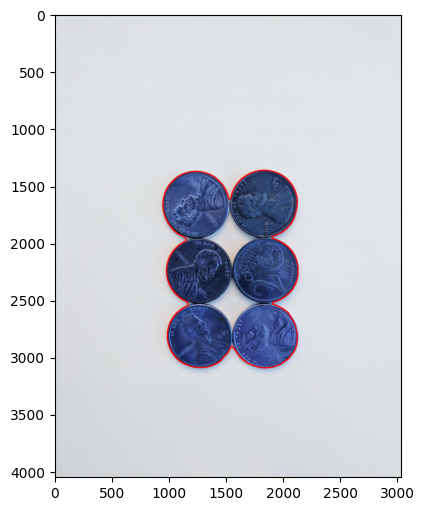

In [14]:
display(sep_coins)

In [16]:
img = cv2.imread(r'C:\Users\arpit\Desktop\Image_Fundamentals\Udemy_Pierian_Data_OpenCV\Computer-Vision-with-Python\DATA\pennies.jpg')

In [17]:
img = cv2.medianBlur(img,35)

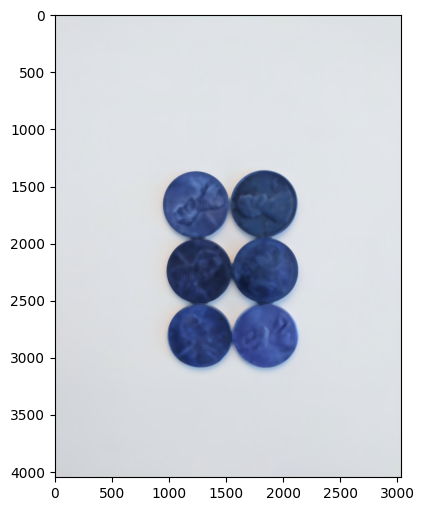

In [18]:
display(img)

In [19]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [20]:
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

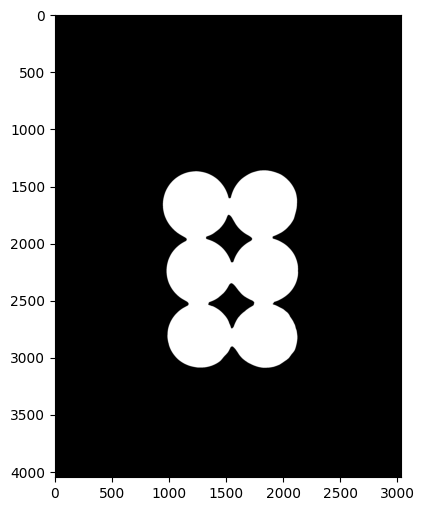

In [21]:
display(thresh)

Noise Removal(Optional)

In [22]:
kernel = np.ones((3,3),np.uint8)

In [23]:
kernel

array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8)

In [24]:
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel,iterations=2)

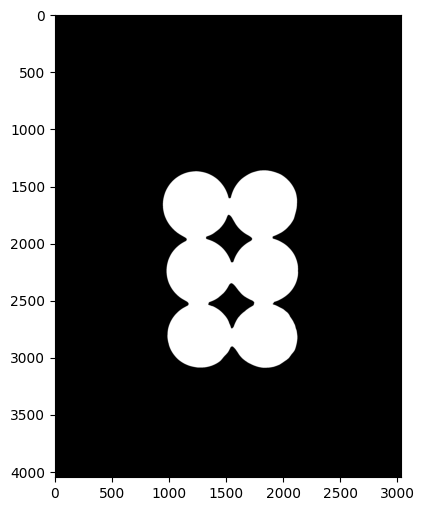

In [25]:
display(opening)

In [33]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)

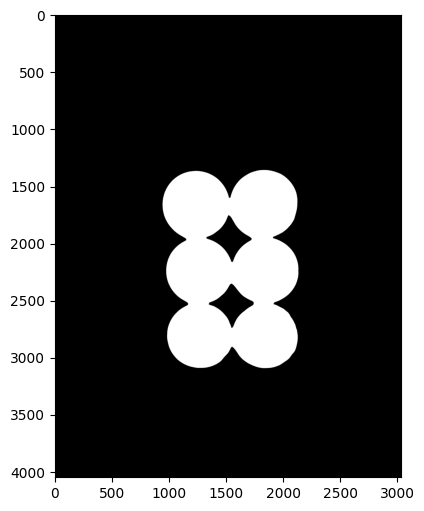

In [34]:
display(sure_bg)

## Distance Transform

In [26]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5) 

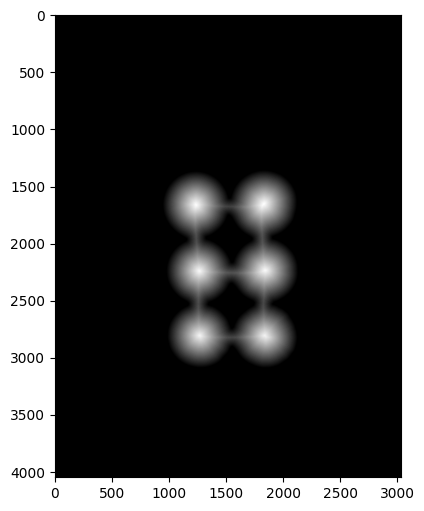

In [27]:
display(dist_transform)

In [28]:
ret,sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(),255,0)

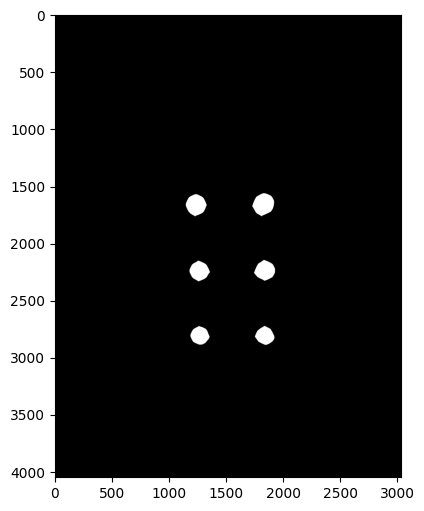

In [29]:
display(sure_fg)

In [31]:
sure_fg = np.uint8(sure_fg)

In [35]:
unknown = cv2.subtract(sure_bg,sure_fg)

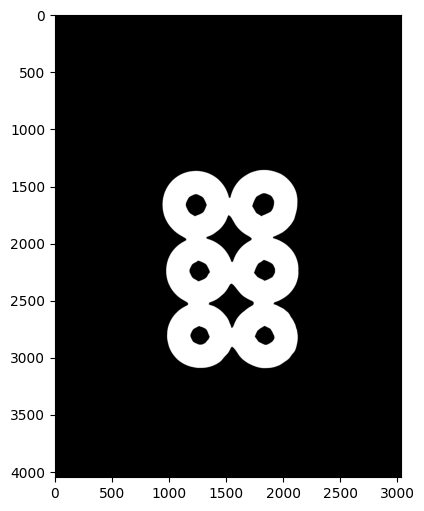

In [36]:
display(unknown)

### Foreground points(Markers) as seeds to Watershed Algo

In [37]:
ret, markers = cv2.connectedComponents(sure_fg)

Making sure background 1 and not 0


In [38]:
markers = markers + 1

Setting the white donut part in unknown to zero

In [39]:
markers[unknown==255] = 0

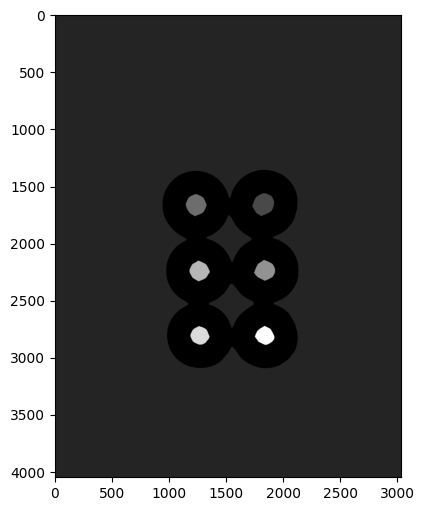

In [40]:
display(markers)

In [41]:
markers = cv2.watershed(img, markers)

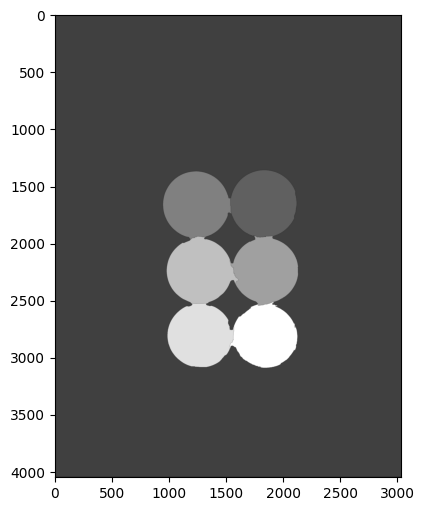

In [42]:
display(markers)

In [45]:
contours,heirarchy = cv2.findContours(markers.copy(),cv2.RETR_CCOMP,cv2.CHAIN_APPROX_SIMPLE)

In [48]:
for i in range(len(contours)):

  if heirarchy[0][i][3] == -1:
    cv2.drawContours(sep_coins,contours,i,(255,0,0),10)

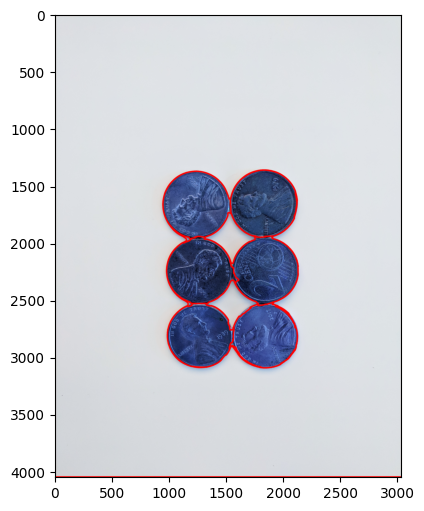

In [49]:
display(sep_coins)